In [1]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


Download Dataset

In [3]:
!wget -q https://github.com/ieee8023/covid-chestxray-dataset/archive/refs/heads/master.zip

In [6]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"apusanaz","key":"be58e188ec11219736bcf14d6ac09e84"}'}

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!pip install -q kaggle

In [9]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:14<00:00, 168MB/s]



Extract

In [10]:
import zipfile

zip_path = "/content/chest-xray-pneumonia.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")

print("Extraction completed!")

Extraction completed!


In [11]:
import os

os.listdir("/content")

['.config',
 'kaggle.json',
 'chest-xray-pneumonia.zip',
 'master.zip',
 'chest_xray',
 'sample_data']

Check Dataset Structure

In [12]:
os.listdir("/content/chest_xray")

['train', 'val', 'test', '__MACOSX', 'chest_xray']

Dataset Class Distribution

In [13]:
import os

base_path = "/content/chest_xray"

for folder in ["train", "test", "val"]:
    print("\n", folder)

    normal = len(os.listdir(f"{base_path}/{folder}/NORMAL"))
    pneumonia = len(os.listdir(f"{base_path}/{folder}/PNEUMONIA"))

    print("NORMAL:", normal)
    print("PNEUMONIA:", pneumonia)


 train
NORMAL: 1341
PNEUMONIA: 3875

 test
NORMAL: 234
PNEUMONIA: 390

 val
NORMAL: 8
PNEUMONIA: 8


Exploratory Data Analysis (EDA)

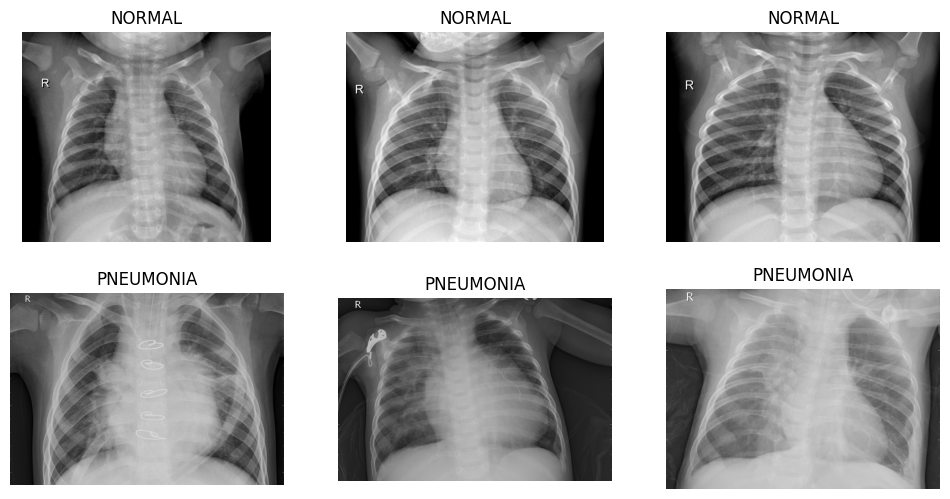

In [14]:
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

normal_path = "/content/chest_xray/train/NORMAL"
pneumonia_path = "/content/chest_xray/train/PNEUMONIA"

normal_images = os.listdir(normal_path)
pneumonia_images = os.listdir(pneumonia_path)

plt.figure(figsize=(12,6))

for i in range(3):
    img_name = random.choice(normal_images)
    img = Image.open(os.path.join(normal_path, img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")


for i in range(3):
    img_name = random.choice(pneumonia_images)
    img = Image.open(os.path.join(pneumonia_path, img_name))

    plt.subplot(2,3,i+4)
    plt.imshow(img, cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.show()

Create Data Generators

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


IMG_SIZE = (224, 224)
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)


test_datagen = ImageDataGenerator(
    rescale=1./255
)


train_data = train_datagen.flow_from_directory(
    "/content/chest_xray/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)


test_data = test_datagen.flow_from_directory(
    "/content/chest_xray/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Build CNN Model (Baseline)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


model = Sequential()


# First Convolution Block
model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(224,224,3)
    )
)

model.add(MaxPooling2D(2,2))


# Second Convolution Block
model.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

model.add(MaxPooling2D(2,2))


# Third Convolution Block
model.add(
    Conv2D(
        128,
        (3,3),
        activation="relu"
    )
)

model.add(MaxPooling2D(2,2))


# Classification Layer
model.add(Flatten())

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(Dropout(0.5))


# Output Layer
model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [17]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


Train CNN Model

In [18]:
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data,
    callbacks=[early_stop]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 678ms/step - accuracy: 0.8144 - loss: 0.4207 - val_accuracy: 0.7981 - val_loss: 0.4235
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 652ms/step - accuracy: 0.8867 - loss: 0.2754 - val_accuracy: 0.8317 - val_loss: 0.3607
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 661ms/step - accuracy: 0.9039 - loss: 0.2439 - val_accuracy: 0.7965 - val_loss: 0.4469
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 655ms/step - accuracy: 0.9160 - loss: 0.2106 - val_accuracy: 0.7596 - val_loss: 0.6017
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 650ms/step - accuracy: 0.9231 - loss: 0.1979 - val_accuracy: 0.7965 - val_loss: 0.5495


Plot Training History

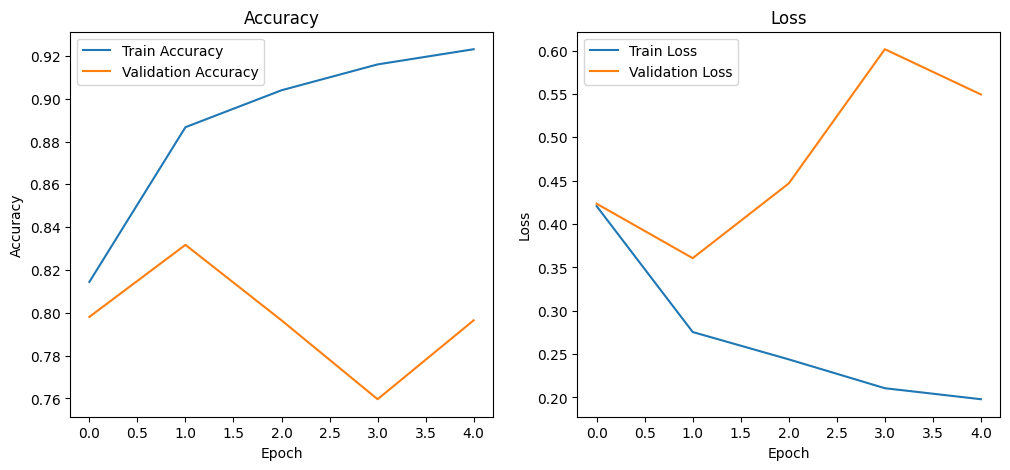

In [19]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.show()

Evaluate Current Model

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


predictions = model.predict(test_data)

predicted_classes = (predictions > 0.5).astype(int)


print(
    classification_report(
        test_data.classes,
        predicted_classes
    )
)


print(
    confusion_matrix(
        test_data.classes,
        predicted_classes
    )
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 306ms/step
              precision    recall  f1-score   support

           0       0.72      0.89      0.80       234
           1       0.92      0.80      0.86       390

    accuracy                           0.83       624
   macro avg       0.82      0.84      0.83       624
weighted avg       0.85      0.83      0.83       624

[[208  26]
 [ 79 311]]


Create a Validation Split

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "/content/chest_xray/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

val_data = train_datagen.flow_from_directory(
    "/content/chest_xray/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=42
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    "/content/chest_xray/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Build a New CNN

In [22]:
import tensorflow as tf
tf.keras.backend.clear_session()

Build Model

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


model = Sequential()


# First Convolution Block
model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(224,224,3)
    )
)

model.add(MaxPooling2D(2,2))


# Second Convolution Block
model.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

model.add(MaxPooling2D(2,2))


# Third Convolution Block
model.add(
    Conv2D(
        128,
        (3,3),
        activation="relu"
    )
)

model.add(MaxPooling2D(2,2))


# Classification Layer
model.add(Flatten())

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(Dropout(0.5))


# Output Layer
model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [24]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Train Model

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 114s 842ms/step - accuracy: 0.8246 - loss: 0.4197 - val_accuracy: 0.8591 - val_loss: 0.3082
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 790ms/step - accuracy: 0.8893 - loss: 0.2773 - val_accuracy: 0.9022 - val_loss: 0.2354
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 787ms/step - accuracy: 0.9022 - loss: 0.2415 - val_accuracy: 0.9032 - val_loss: 0.2061
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 798ms/step - accuracy: 0.8974 - loss: 0.2484 - val_accuracy: 0.8888 - val_loss: 0.2293
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 795ms/step - accuracy: 0.9113 - loss: 0.2149 - val_accuracy: 0.9147 - val_loss: 0.1955
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 790ms/step - accuracy: 0.9147 - loss: 0.2083 - val_accuracy: 0.9319 - val_loss: 0.1761
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 781ms/step - accuracy: 0.9262 - loss: 0.1968 - val_accuracy: 0.9108 - val_loss: 0.2035
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 801ms/step - accuracy: 0.9231 -

Final Evaluation

In [26]:
test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - accuracy: 0.7500 - loss: 0.5846
Test Loss: 0.5846
Test Accuracy: 0.7500


In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

predictions = model.predict(test_data)
predicted_classes = (predictions > 0.5).astype(int)

print(classification_report(test_data.classes, predicted_classes))

print(confusion_matrix(test_data.classes, predicted_classes))

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step
              precision    recall  f1-score   support

           0       0.95      0.35      0.51       234
           1       0.72      0.99      0.83       390

    accuracy                           0.75       624
   macro avg       0.84      0.67      0.67       624
weighted avg       0.81      0.75      0.71       624

[[ 82 152]
 [  4 386]]


Transfer Learning (MobileNetV2)

In [28]:
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

Load Pre-trained Model

In [29]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Build Transfer Learning Model

In [30]:
inputs = tf.keras.Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

x = Dense(128, activation="relu")(x)

outputs = Dense(1, activation="sigmoid")(x)

mobilenet_model = Model(inputs, outputs)

mobilenet_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Compile Model

In [31]:
mobilenet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Train Model

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_mobile = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.9188 - loss: 0.1848 - val_accuracy: 0.9444 - val_loss: 0.1395
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 797ms/step - accuracy: 0.9413 - loss: 0.1388 - val_accuracy: 0.9501 - val_loss: 0.1196
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 814ms/step - accuracy: 0.9506 - loss: 0.1231 - val_accuracy: 0.9578 - val_loss: 0.1172
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 792ms/step - accuracy: 0.9485 - loss: 0.1291 - val_accuracy: 0.9588 - val_loss: 0.1007
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 784ms/step - accuracy: 0.9533 - loss: 0.1211 - val_accuracy: 0.9569 - val_loss: 0.0943
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 101s 773ms/step - accuracy: 0.9526 - loss: 0.1174 - val_accuracy: 0.9549 - val_loss: 0.1027
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 101s 776ms/step - accuracy: 0.9509 - loss: 0.1221 - val_accuracy: 0.9559 - val_loss: 0.1190
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 785ms/step - accuracy: 0.9547 - lo

Final Evaluation/ Evaluate on Test Set

In [33]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_data)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 846ms/step - accuracy: 0.8798 - loss: 0.2899
Test Loss: 0.2899
Test Accuracy: 0.8798


Classification Report

In [34]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

predictions = mobilenet_model.predict(test_data)
predicted_classes = (predictions > 0.5).astype(int)

print(classification_report(test_data.classes, predicted_classes))

print(confusion_matrix(test_data.classes, predicted_classes))

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 480ms/step
              precision    recall  f1-score   support

           0       0.96      0.71      0.81       234
           1       0.85      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.91      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624

[[165  69]
 [  6 384]]


Import EfficientNetB0

In [35]:
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model

Load Pre-trained Model

In [36]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Build EfficientNet Model

In [37]:
inputs = tf.keras.Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

x = Dense(128, activation="relu")(x)

outputs = Dense(1, activation="sigmoid")(x)

efficientnet_model = Model(inputs, outputs)

efficientnet_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Compile Model

In [38]:
efficientnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Train Model

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_efficient = efficientnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.7429 - loss: 0.5824 - val_accuracy: 0.7430 - val_loss: 0.5720
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 832ms/step - accuracy: 0.7429 - loss: 0.5729 - val_accuracy: 0.7430 - val_loss: 0.5728
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 793ms/step - accuracy: 0.7429 - loss: 0.5751 - val_accuracy: 0.7430 - val_loss: 0.5711
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 783ms/step - accuracy: 0.7429 - loss: 0.5740 - val_accuracy: 0.7430 - val_loss: 0.5707
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 803ms/step - accuracy: 0.7429 - loss: 0.5761 - val_accuracy: 0.7430 - val_loss: 0.5759
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 797ms/step - accuracy: 0.7429 - loss: 0.5723 - val_accuracy: 0.7430 - val_loss: 0.5791
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 801ms/step - accuracy: 0.7429 - loss: 0.5728 - val_accuracy: 0.7430 - val_loss: 0.5754


Evaluate Model

In [40]:
test_loss, test_accuracy = efficientnet_model.evaluate(test_data)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 838ms/step - accuracy: 0.6250 - loss: 0.7080
Test Loss: 0.7080
Test Accuracy: 0.6250


Classification Report

In [41]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

predictions = efficientnet_model.predict(test_data)
predicted_classes = (predictions > 0.5).astype(int)

print(classification_report(test_data.classes, predicted_classes))
print(confusion_matrix(test_data.classes, predicted_classes))

20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 628ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       234
           1       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624

[[  0 234]
 [  0 390]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:
efficientnet_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,541,864 (17.33 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 328,196 (1.25 MB)

In [43]:
print(base_model.trainable)

False


Fine-Tuning EfficientNetB0/ Unfreeze the Last Layers

In [44]:
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable layers:",
      sum([layer.trainable for layer in base_model.layers]))

Trainable layers: 30


Compile with a Small Learning Rate

In [45]:
from tensorflow.keras.optimizers import Adam

efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Fine-Tune the Model

In [46]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_finetune = efficientnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.7297 - loss: 0.6077 - val_accuracy: 0.7430 - val_loss: 0.5716
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 790ms/step - accuracy: 0.7431 - loss: 0.5771 - val_accuracy: 0.7430 - val_loss: 0.5705
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 811ms/step - accuracy: 0.7417 - loss: 0.5758 - val_accuracy: 0.7430 - val_loss: 0.5835
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 791ms/step - accuracy: 0.7426 - loss: 0.5772 - val_accuracy: 0.7430 - val_loss: 0.5846
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 782ms/step - accuracy: 0.7426 - loss: 0.5718 - val_accuracy: 0.7430 - val_loss: 0.5791


In [47]:
test_loss, test_accuracy = efficientnet_model.evaluate(test_data)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 463ms/step - accuracy: 0.6250 - loss: 0.6883
Test Loss: 0.6883
Test Accuracy: 0.6250


In [48]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

predictions = efficientnet_model.predict(test_data)
predicted_classes = (predictions > 0.5).astype(int)

print(classification_report(test_data.classes, predicted_classes))
print(confusion_matrix(test_data.classes, predicted_classes))

20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 836ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       234
           1       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624

[[  0 234]
 [  0 390]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Plot Accuracy and Loss Curves/ Training & Validation Accuracy

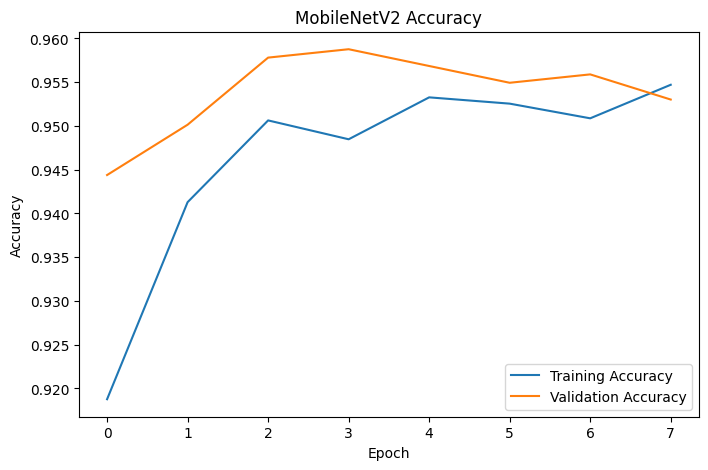

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_mobile.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobile.history['val_accuracy'], label='Validation Accuracy')

plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Training & Validation Loss

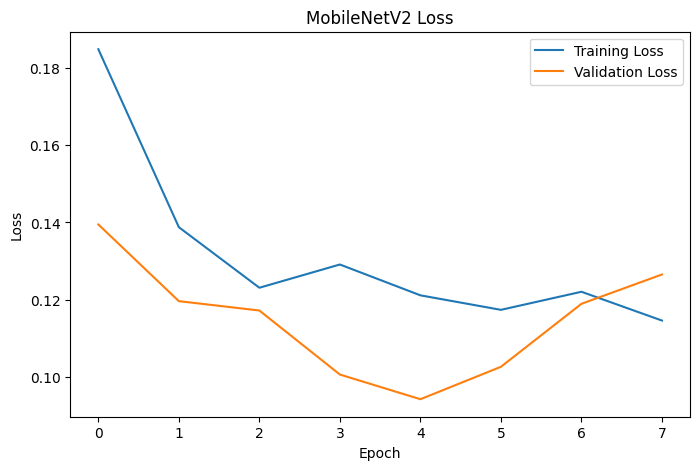

In [50]:
plt.figure(figsize=(8,5))

plt.plot(history_mobile.history['loss'], label='Training Loss')
plt.plot(history_mobile.history['val_loss'], label='Validation Loss')

plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

ROC Curve & AUC

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 270ms/step


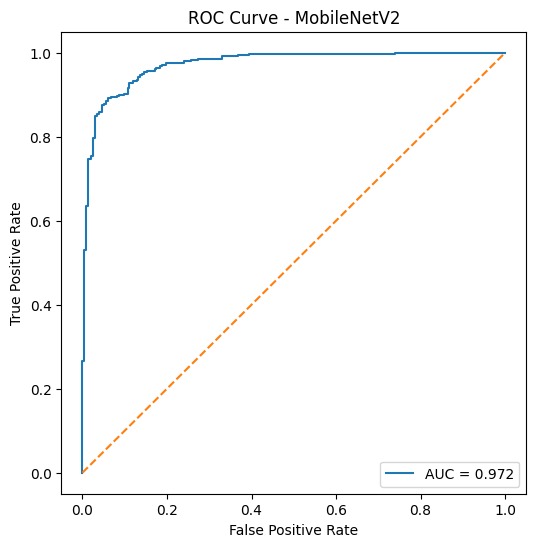

AUC: 0.971937321937322


In [51]:
from sklearn.metrics import roc_curve, auc

probabilities = mobilenet_model.predict(test_data).ravel()

fpr, tpr, thresholds = roc_curve(test_data.classes, probabilities)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - MobileNetV2')
plt.legend()

plt.show()

print("AUC:", roc_auc)

Select a Test Image

In [52]:
import os
import random

test_normal = "/content/chest_xray/test/NORMAL"
test_pneumonia = "/content/chest_xray/test/PNEUMONIA"

image_path = random.choice(
    [os.path.join(test_pneumonia, f) for f in os.listdir(test_pneumonia)]
)

print(image_path)

/content/chest_xray/test/PNEUMONIA/person93_bacteria_454.jpeg


Display the Image

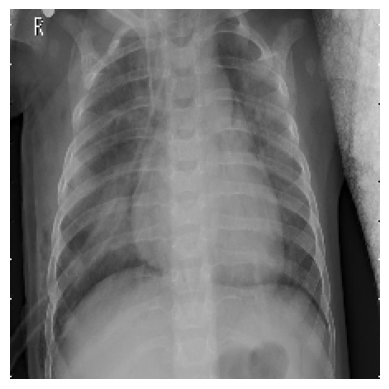

In [53]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img = image.load_img(image_path, target_size=(224,224))

plt.imshow(img)
plt.axis("off")
plt.show()

Find Last Convolutional Layer

In [54]:
# Show MobileNetV2 layers

for layer in mobilenet_model.layers:
    print(layer.name)

input_layer_2
mobilenetv2_1.00_224
global_average_pooling2d
dropout_1
dense_2
dense_3


In [55]:
base_model = mobilenet_model.layers[1]

for layer in base_model.layers[-10:]:
    print(layer.name)

block_16_expand_BN
block_16_expand_relu
block_16_depthwise
block_16_depthwise_BN
block_16_depthwise_relu
block_16_project
block_16_project_BN
Conv_1
Conv_1_bn
out_relu


reate Grad-CAM Function

In [56]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # MobileNetV2 backbone
    base_model = model.get_layer("mobilenetv2_1.00_224")

    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            last_conv_layer.output,
            base_model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        # prediction score
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

Prepare Image for Model

In [57]:
img = image.load_img(
    image_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

Generate Heatmap

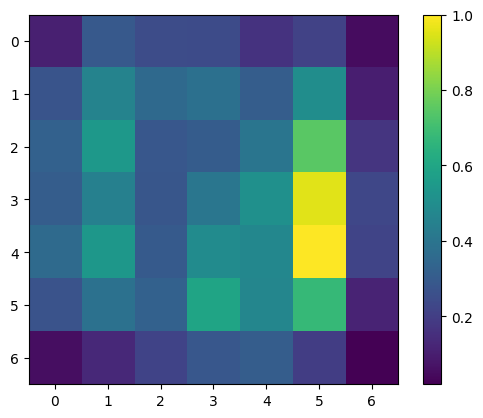

In [58]:
heatmap = make_gradcam_heatmap(
    img_array,
    mobilenet_model,
    "out_relu"
)

plt.imshow(heatmap)
plt.colorbar()
plt.show()

Overlay Grad-CAM on X-ray

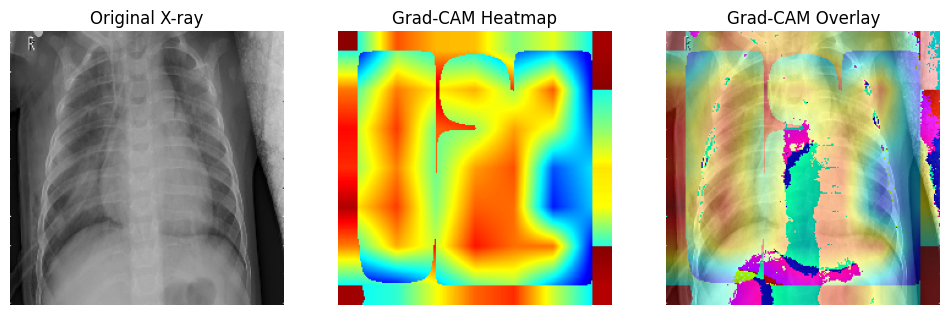

In [60]:
# Resize heatmap to image size
heatmap = cv2.resize(
    heatmap,
    (224,224)
)

# Convert heatmap to 0-255
heatmap = np.uint8(255 * heatmap)

# Apply color map
heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

# Load original image
img = cv2.imread(image_path)

img = cv2.resize(img, (224,224))

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

# Overlay
superimposed_img = heatmap * 0.4 + img

superimposed_img = np.uint8(superimposed_img)


plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original X-ray")
plt.axis("off")


plt.subplot(1,3,2)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")


plt.subplot(1,3,3)
plt.imshow(superimposed_img)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.show()

Final Comparison Table

In [61]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "MobileNetV2",
        "EfficientNetB0"
    ],

    "Test Accuracy": [
        0.7500,
        0.8798,
        0.6250
    ],

    "Test Loss": [
        0.5846,
        0.2899,
        0.6883
    ],

    "Precision": [
        0.81,
        0.89,
        0.39
    ],

    "Recall": [
        0.75,
        0.88,
        0.62
    ],

    "F1-score": [
        0.71,
        0.87,
        0.48
    ]
})


# Convert values to percentage
comparison_display = comparison.copy()

comparison_display["Test Accuracy"] = (
    comparison_display["Test Accuracy"] * 100
).round(2).astype(str) + "%"


comparison_display["Test Loss"] = (
    comparison_display["Test Loss"]
).round(4)


comparison_display["Precision"] = (
    comparison_display["Precision"] * 100
).round(2).astype(str) + "%"


comparison_display["Recall"] = (
    comparison_display["Recall"] * 100
).round(2).astype(str) + "%"


comparison_display["F1-score"] = (
    comparison_display["F1-score"] * 100
).round(2).astype(str) + "%"


comparison_display

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-score
0,Baseline CNN,75.0%,0.5846,81.0%,75.0%,71.0%
1,MobileNetV2,87.98%,0.2899,89.0%,88.0%,87.0%
2,EfficientNetB0,62.5%,0.6883,39.0%,62.0%,48.0%


ROC Curve / MobileNetV2 (Best Model)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step
AUC Score: 0.971937321937322


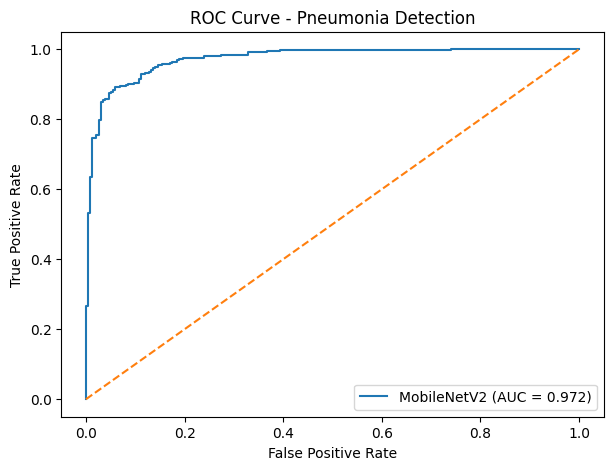

In [62]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get prediction probabilities
y_pred_prob = mobilenet_model.predict(test_data).ravel()

# True labels
y_true = test_data.classes

# ROC points
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_pred_prob
)

# Calculate AUC
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)


# Plot ROC Curve

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"MobileNetV2 (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Pneumonia Detection")

plt.legend()

plt.show()

In [63]:
mobilenet_model.save("mobilenet_pneumonia.keras")